In [1]:
from myutils import parallelize

from scipy.optimize import minimize
from src import *
from src.fisherinfo import ApproxFisherInformation

from scipy.special import erf, factorial

In [3]:
freq_list = np.linspace(0.1, 0.4, 1001)

sampling_rate = 20
pic_time = (1 / (sampling_rate * freq_list) / 2 * 1e6).astype(int)

# Consider rounding errors
# real_freq_list = 1 / (pic_time * 2) * 1e6 / sampling_rate

In [ ]:
@parallelize()
def main(f, measurement, A):
    cropped, background = [], []
    for _ in range(200):
        meta = MetaData(measurement, f, 'frequency', A, 0)
        meta_ = MetaData(measurement, np.round(f, 5), 'frequency', A, 0) # MetaData for save file, match the experiments.
        sim = Simulator(meta, delay=0, waveform='sign')
        cropped_, background_ = sim.gen()
        cropped.append(cropped_)
        background.append(background_)
    c = Estimates(np.array(cropped), meta_, background=np.array(background).mean(-1))

    c_ = Estimation.FromEstimates(c)
    c_.savez('TEMP')

    # return Estimation.FromEstimates(c)

In [ ]:
_ = main(freq_list, 'DI', 3*DMD.PIXEL_SIZE/2), main(freq_list, 'SPADE', 3*DMD.PIXEL_SIZE/2)

In [4]:
cs_di = [LoadEstimates(f'TEMP/di_3px_f{np.round(f, 5)}_d0.npz') for f in freq_list]
cs_spade = [LoadEstimates(f'TEMP/spade_3px_f{np.round(f, 5)}_d0.npz') for f in freq_list]

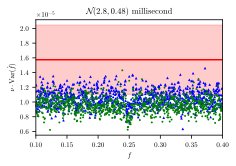

In [5]:
c1 = 'b'
c2 = 'g'

red = 'r'


plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['figure.figsize'] = (8.5/2.54, 8.5/2.54)

di_y = [cs_di[i].estimates_a.var() * cs_di[i].photons.mean() for i in range(1001)]
spade_y = [cs_spade[i].estimates_a.var() * cs_spade[i].photons.mean() for i in range(1001)]

plt.plot(freq_list, spade_y, 
        marker='^', linestyle='', markersize=1,
        markeredgecolor=c1, markerfacecolor=(c1, 0.3))

plt.plot(freq_list, di_y,
        marker='o', linestyle='', markersize=1,
        markeredgecolor=c2, markerfacecolor=(c2, 0.3))


crb = list(1 / ApproxFisherInformation([3*DMD.PIXEL_SIZE/2])) * 1001
plt.plot(freq_list, crb, red)
plt.fill_between(freq_list, 0.7 * np.array(crb), 1.3 * np.array(crb), color=red, alpha=0.2)

plt.xlim(0.1, 0.4)
plt.title(r'$\mathcal{N}(2.8, 0.48)$ millisecond')
plt.xlabel(r'$f$')
plt.ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')

plt.gca().set_box_aspect(0.618)
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='sci', axis='y')

plt.show()